# On-Sky MCMC Tutorial

This is the same idea as the global MCMC fit for the internal calibrations. I won't add much comments since the process is the same, except you use your on-sky CSV and data. There is a `.py` script version of this notebook in the `mcmc_scripts` folder.

In [1]:
# IMPORTING DATA

from pyPolCal.csv_tools import read_csv_physical_model_all_bins
from importlib.resources import files
from pathlib import Path

# Defining Path to my CSVs
csvdir = Path('/home/thomasmc/pyPolCal/pyPolCal/CHARIS/datacsvs/onsky_nbs/HD293396')

# Reading in data
interleaved_values_all, interleaved_stds_all, configuration_list_all = read_csv_physical_model_all_bins(csvdir, m3=True)

/home/thomasmc/miniconda3/envs/charisenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# GENERATE MODEL
from pyPolCal.utils import generate_system_mueller_matrix

system_dict = {
    "components" : {
        "wollaston" : {
        "type" : "fitted_wollaston_function_12_28_2025",
        "properties" : {"beam": 'o'}, 
        "tag": "internal",
        },

        "nbs_rot": {
            "type": "rotator_function",
            "properties": {"pa": 90},
            "tag": "internal",
        },
        "image_rotator" : {
        "type" : "fitted_derotator_function_12_28_2025",
        "properties" : {"delta_theta":1.384e-02}, 
        "tag": "internal",
        },
        
        "hwp" : {
            "type" : "two_layer_HWP_function", # Joost 't Hart 2021 HWP model
            "properties" : {"w_SiO2":1.653, "w_MgF2":1.291, "delta_theta": -3.168e-02},
            "tag": "internal",
        },

        "altitude_rot" : {
            "type" : "rotator_function",
            "properties" : {"pa":0},
            "tag":"internal",
        },
        "M3" : {
            "type" : "SUBARU_M3_function",
            "properties" : {"delta_theta":0},
            "tag": "internal",
        },

        "parang_rot" : {
            "type" : "rotator_function",
            "properties" : {"pa":0},
            "tag":"internal",
        },
        },
}
system_mm = generate_system_mueller_matrix(system_dict)
system_mm.evaluate()

array([[ 0.48902582, -0.48857441,  0.00881718,  0.01906714],
       [ 0.48902582, -0.48857441,  0.00881718,  0.01906714],
       [ 0.        ,  0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        ]])

In [4]:

# Define starting guesses

m1, b1, m2, b2 = (1.781,12.47,2.264,14.67) # from minimize
p0_dict = {
    "M3":{"m1": m1,
    "b1": b1,
    "m2": m2,
    "b2": b2
    }
}
m1_bounds = (0.5*m1, 2*m1)
m2_bounds = (0.5*m2, 2*m2)
b1_bounds = (0.5*b1, 2*b1)
b2_bounds = (0.5*b2, 2*b2)
boundslist = [m1_bounds, b1_bounds, m2_bounds, b2_bounds]

bounds_dict = {
    
    "M3" : {
        "m1": m1_bounds,
        "b1": b1_bounds,
        "m2": m2_bounds,
        "b2": b2_bounds
    }
}

# Define priors
prior_dict = {

    "M3": {
        "m1": {"type": "uniform", "kwargs": {"low":0.5*m1, "high": 2*m1}},
        "b1": {"type": "uniform", "kwargs": {"low":0.5*b1, "high": 2*b1}},
        "m2": {"type": "uniform", "kwargs": {"low":0.5*m2, "high": 2*m2}},
        "b2": {"type": "uniform", "kwargs": {"low":0.5*b2, "high": 2*b2}},
}}


In [ ]:
from pyPolCal.instruments_mcmc import run_mcmc, process_model, process_dataset , process_errors

# Path for the h5 emcee output file
output_h5 = 'mcmc_tutorial_output_onsky.h5'

ndim = 6  # Number of parameters to fit
pool_processes = 12 # Number of CPU cores to use
nwalkers = max(2 * ndim, pool_processes * 2) # Number of walkers at least twice the number of dimensions
if nwalkers % pool_processes != 0:
    nwalkers += pool_processes - (nwalkers % pool_processes)

print(f"{nwalkers} walkers for {ndim} parameters")
sampler, p_keys = run_mcmc(p0_dict, system_mm, interleaved_values_all,configuration_list_all,prior_dict,bounds_dict,output_h5,errors=interleaved_stds_all,nwalkers=nwalkers,pool_processes=pool_processes,process_model=process_model, process_dataset=process_dataset,process_errors=process_errors,nsteps=7000,test_plot=False, include_sums=False)

In [9]:
# check results
from pyPolCal.plotting import summarize_median_posterior
output_h5 = 'mcmc_tutorial_output_onsky_test_2.h5'
summarize_median_posterior(output_h5,p0_dict,step_range=(1000,10000))

Posterior Medians and 1 sigma Credible Intervals:
M3,m1: 4.76556 (+1.61958/-2.20237)
M3,b1: 14.37763 (+11.18698/-7.66263)
M3,m2: 0.92121 (+0.21034/-0.15938)
M3,b2: 9.11438 (+1.35467/-0.98745)


{'M3': {'m1': {'median': np.float64(4.765558698353098),
   '-1sigma': np.float64(2.2023709596420207),
   '+1sigma': np.float64(1.6195829560597392),
   'map': np.float64(5.148316579931402)},
  'b1': {'median': np.float64(14.3776287473637),
   '-1sigma': np.float64(7.662625359046665),
   '+1sigma': np.float64(11.186983547206188),
   'map': np.float64(27.129171089565652)},
  'm2': {'median': np.float64(0.9212122411415424),
   '-1sigma': np.float64(0.15938124848443902),
   '+1sigma': np.float64(0.21034165643142377),
   'map': np.float64(0.8463872948049299)},
  'b2': {'median': np.float64(9.11437692542816),
   '-1sigma': np.float64(0.9874483284055895),
   '+1sigma': np.float64(1.3546730620527647),
   'map': np.float64(8.583375069139285)}}}

In [7]:
import json
with open('mcmc_p0_onsky.json', 'w') as f:
    json.dump(p0_dict, f)

unique (rounded): [-4.99999984 -4.99999976 -4.99999967 -4.99999949 -4.99999916 -4.99999913
 -4.99999899 -4.99999887 -4.99999859 -4.99999853]
percentiles: [-4.99997905 -4.99943135 -4.99851451 -4.99696067 -4.60840941]


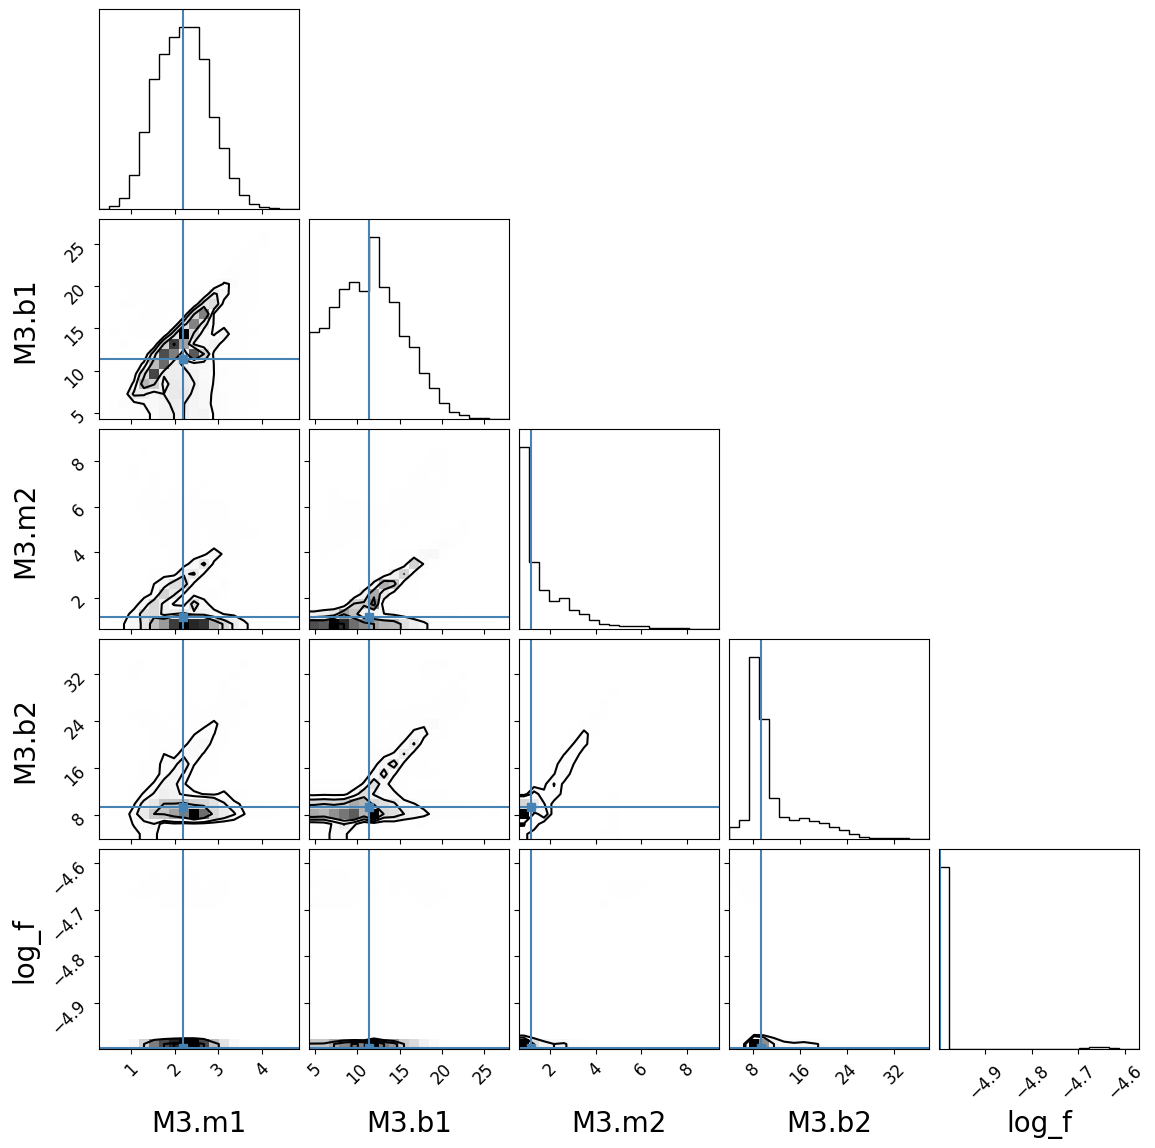

In [8]:
from pyPolCal.plotting import plot_corner_flat, load_chain_and_labels
import numpy as np
chain, names = load_chain_and_labels('mcmc_tutorial_output_onsky_test_uniform_gaussian_m1_bounds.h5', 'mcmc_p0_onsky.json', include_logf=True)
fig, ax = plot_corner_flat(chain, names, step_range=(1000,10000))
logf = chain[:, :, -1]
print("unique (rounded):", np.unique(np.round(logf.reshape(-1), 8))[:10])
print("percentiles:", np.percentile(logf.reshape(-1), [1,25,50,75,99]))

Yikes!